In [1]:
datasets = [
    #"mnist_red30_incremental",
    #"mnist_red30_sml",
    #"fashion_mnist_red50_incremental",
    #"fashion_mnist_red50_sml",
    "fashion_mnist_red50_sml_2",
    "fashion_mnist_red50_sml_3",
    "mnist_red30_sml_2",
    "mnist_red30_sml_3",
]
root = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/SML_CL"
nconfs = 10
save = True
suffixes = []

In [2]:
import pickle
import matplotlib.pyplot as plt
import os 
import numpy as np
import pandas as pd

In [3]:
def plot_kappa(perf_values, root, dataset, perf="concept"):
    plt.figure(figsize=(16, 8))

    values_list = []
    for m in perf_values:
        if m=="drifts":
            continue
        values = perf_values[m][perf]["kappa"]
        for d in [0]+perf_values["drifts"][:-1]:
            values_list.append(values[d+1000])
        plt.plot(range(len(values)), values, label=m)            

    for drift in perf_values["drifts"]:
        plt.axvline(x=drift, color='grey', linestyle='--', linewidth=1)

    plt.xlabel("Data points")
    plt.ylabel("Cohen's Kappa")
    plt.title(f"Prequential {perf} on {dataset}")
    plt.legend()
    # plt.grid()
    plt.ylim(min(values_list),1)
    plt.xlim(0, len(values))

    if save:
        plt.savefig(os.path.join(root,f"{dataset}_prequential_{perf}.png"), bbox_inches='tight')
    display(plt.gcf())
    plt.close(plt.gcf())

fashion_mnist_red50_sml_2 concept


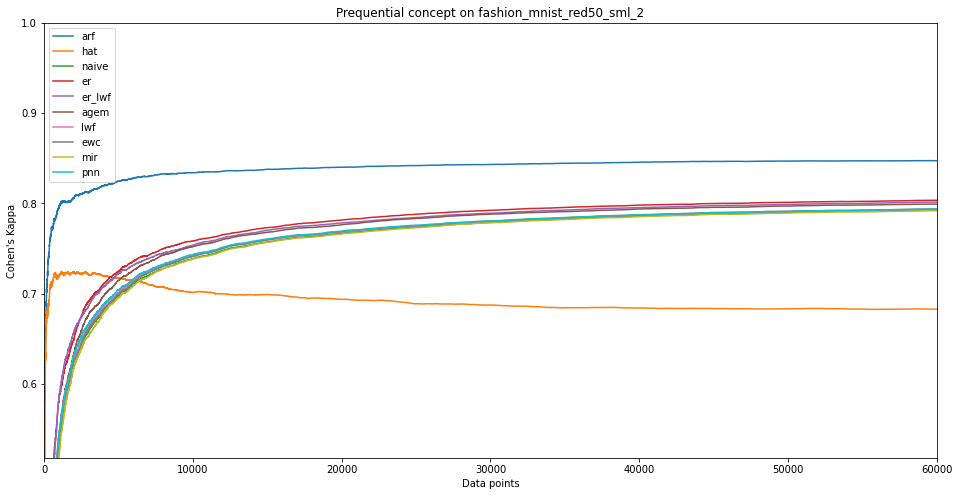

fashion_mnist_red50_sml_2 rolling_500


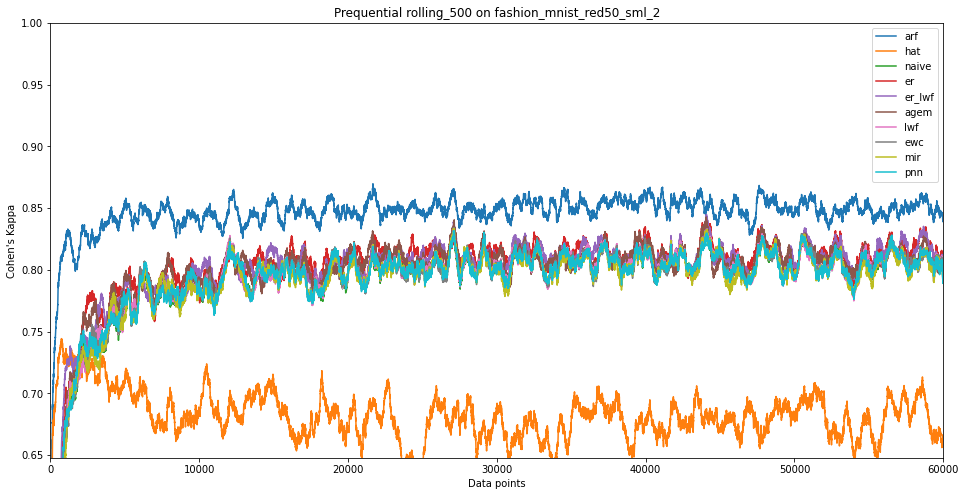

fashion_mnist_red50_sml_2 rolling_1000


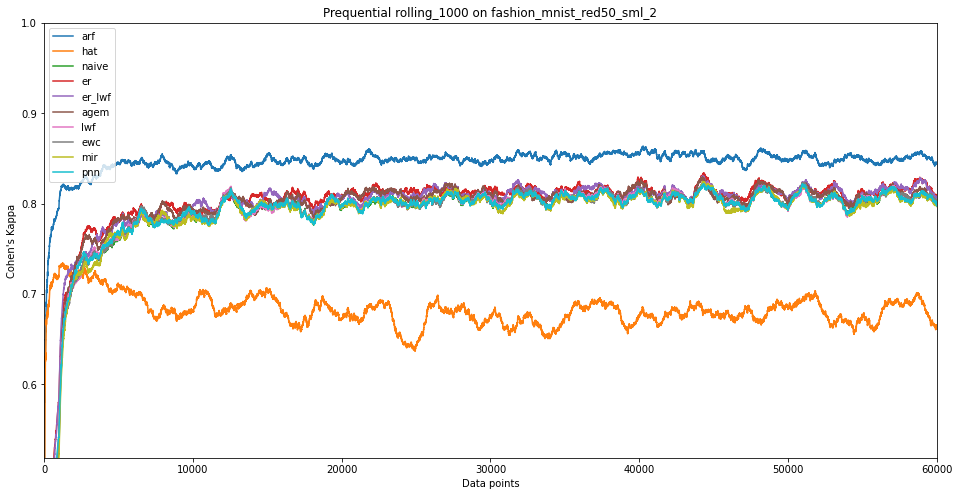

fashion_mnist_red50_sml_2 rolling_5000


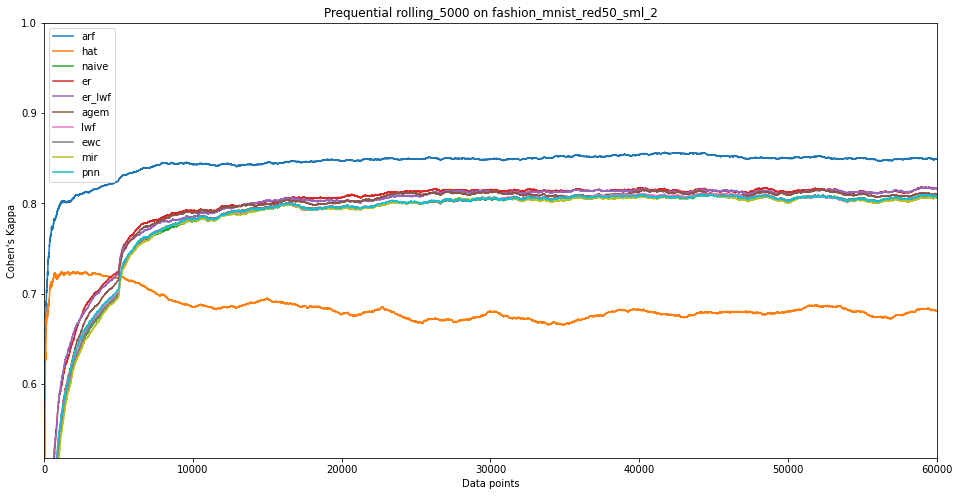


fashion_mnist_red50_sml_3 concept


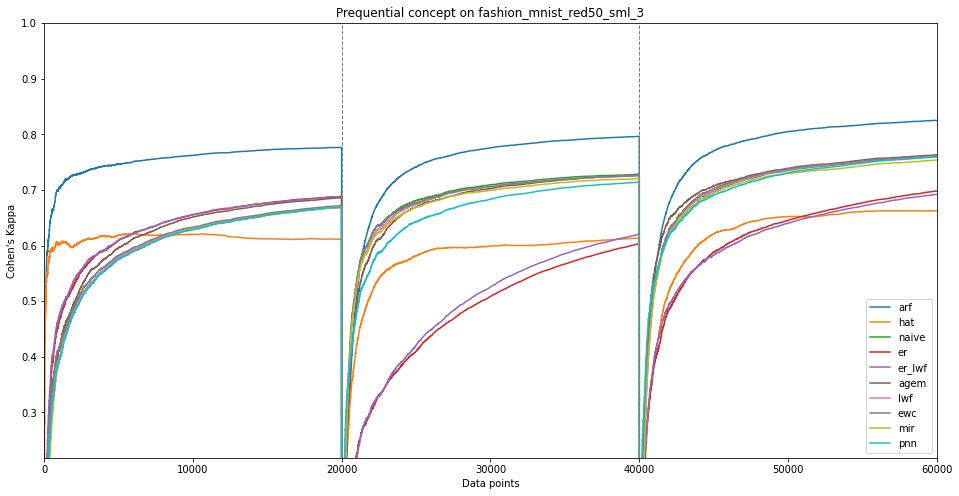

fashion_mnist_red50_sml_3 rolling_500


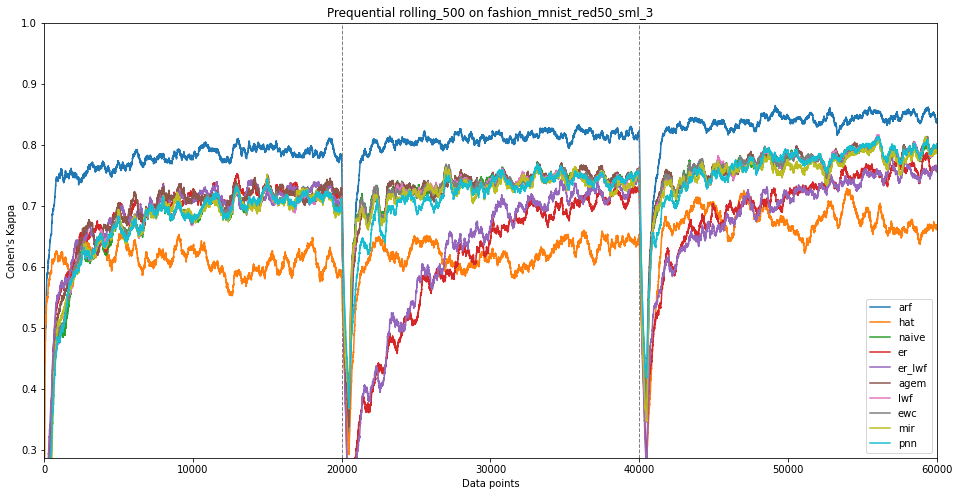

fashion_mnist_red50_sml_3 rolling_1000


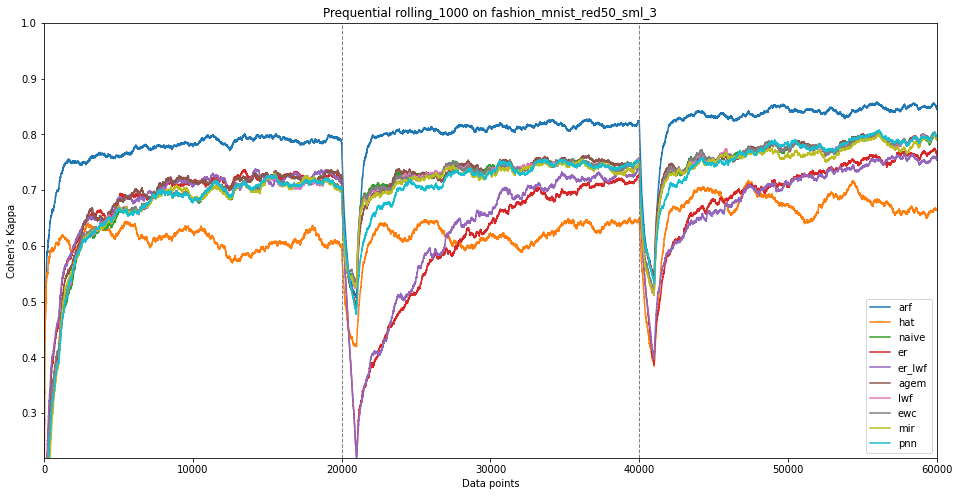

fashion_mnist_red50_sml_3 rolling_5000


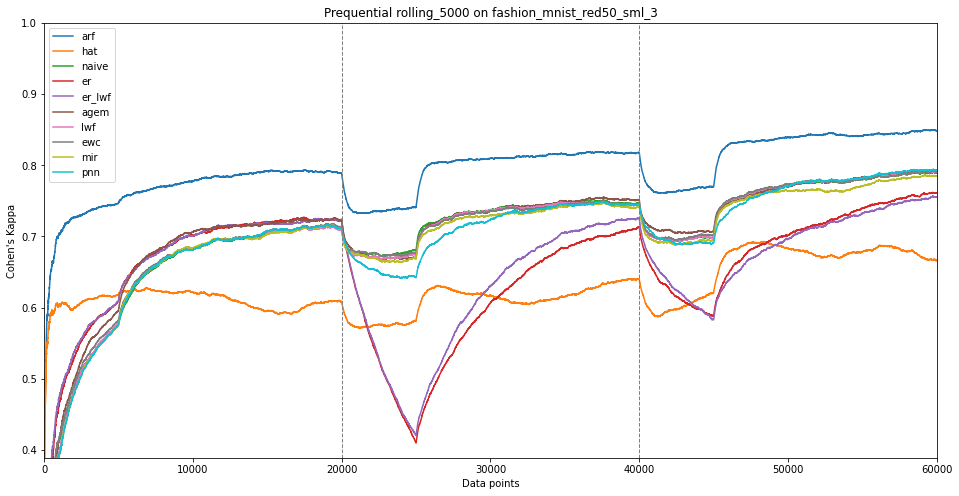


mnist_red30_sml_2 concept


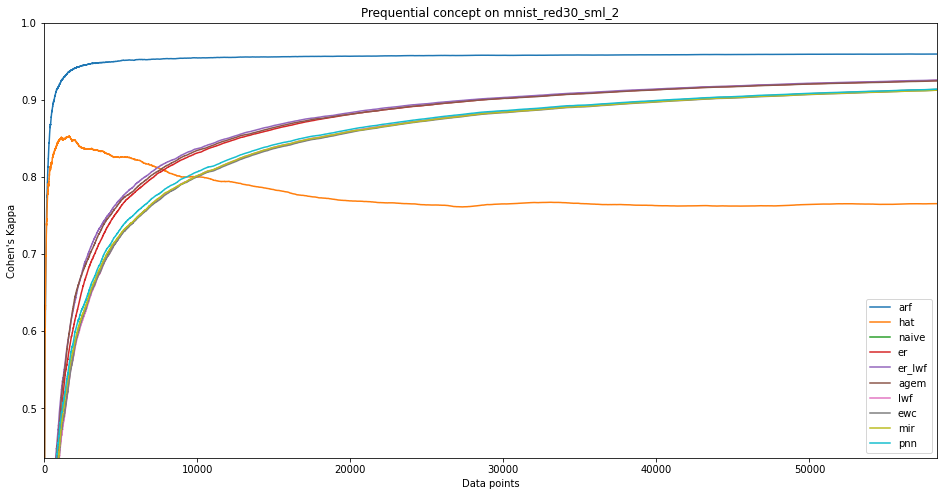

mnist_red30_sml_2 rolling_500


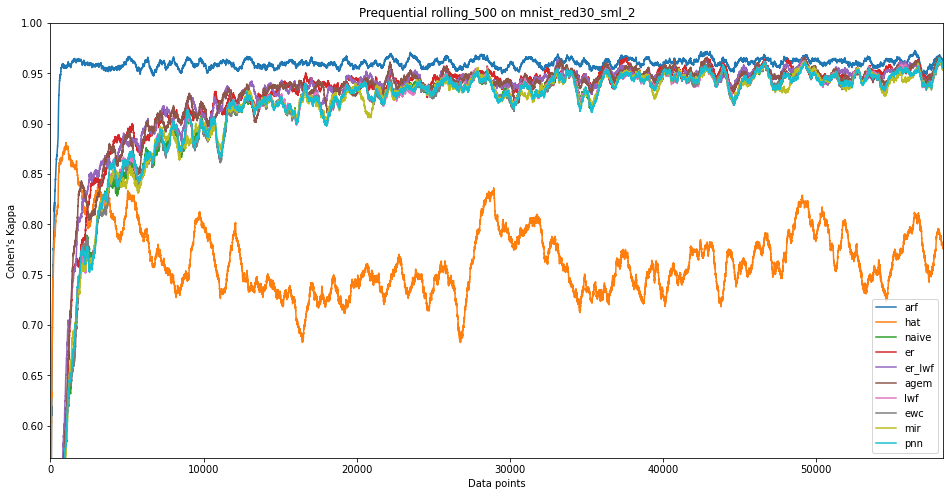

mnist_red30_sml_2 rolling_1000


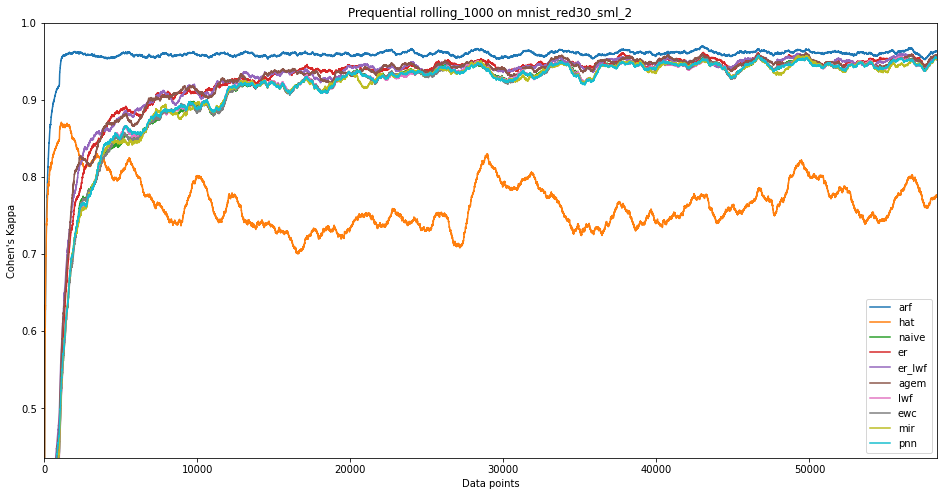

mnist_red30_sml_2 rolling_5000


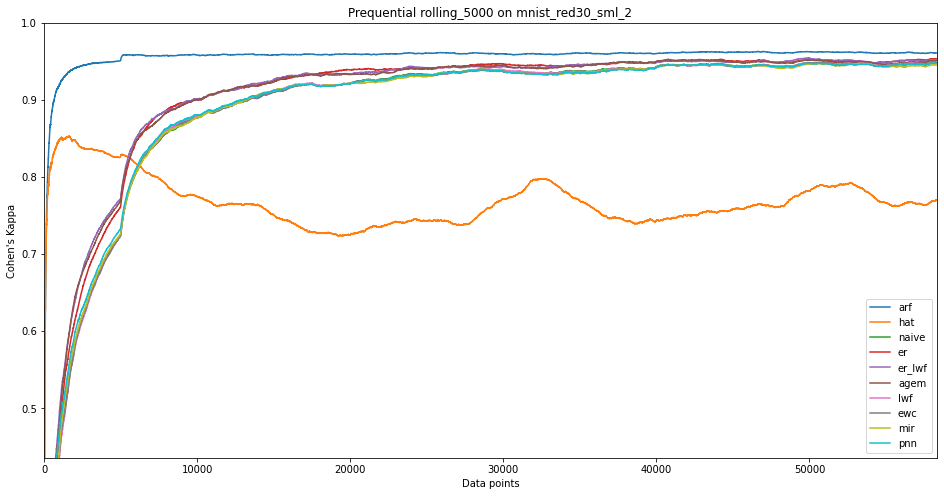


mnist_red30_sml_3 concept


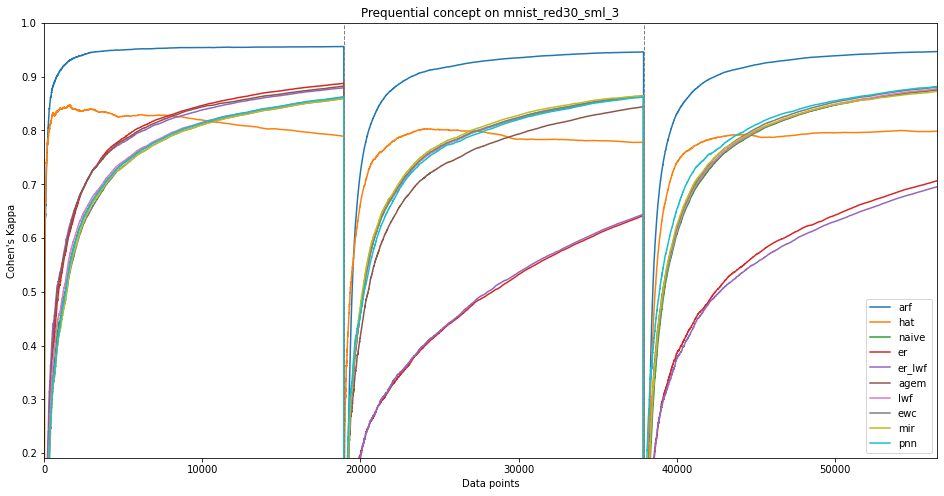

mnist_red30_sml_3 rolling_500


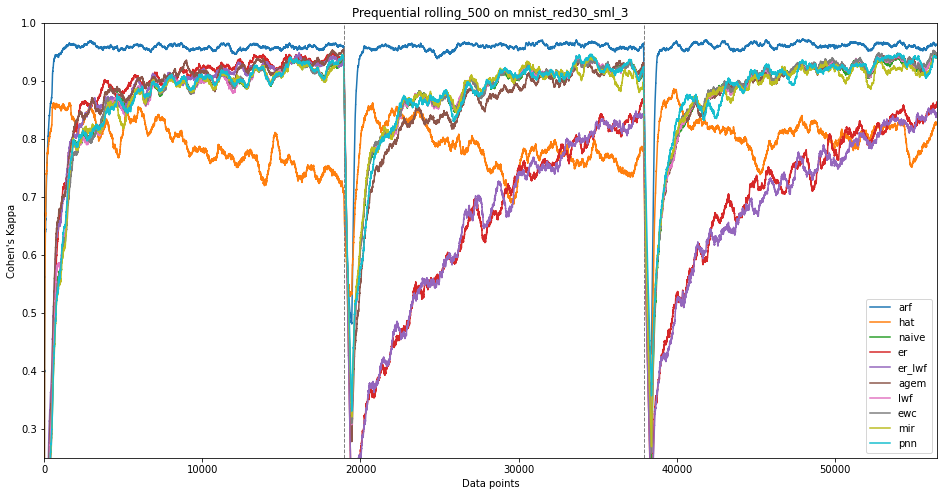

mnist_red30_sml_3 rolling_1000


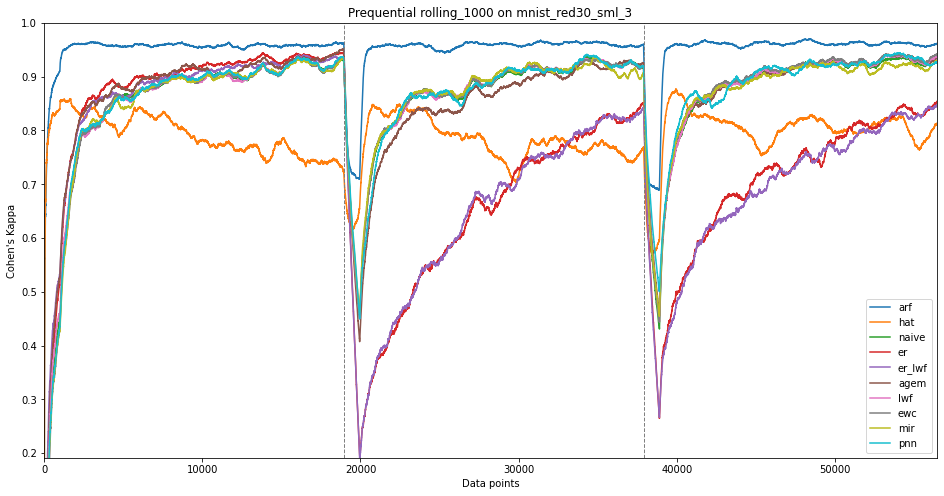

mnist_red30_sml_3 rolling_5000


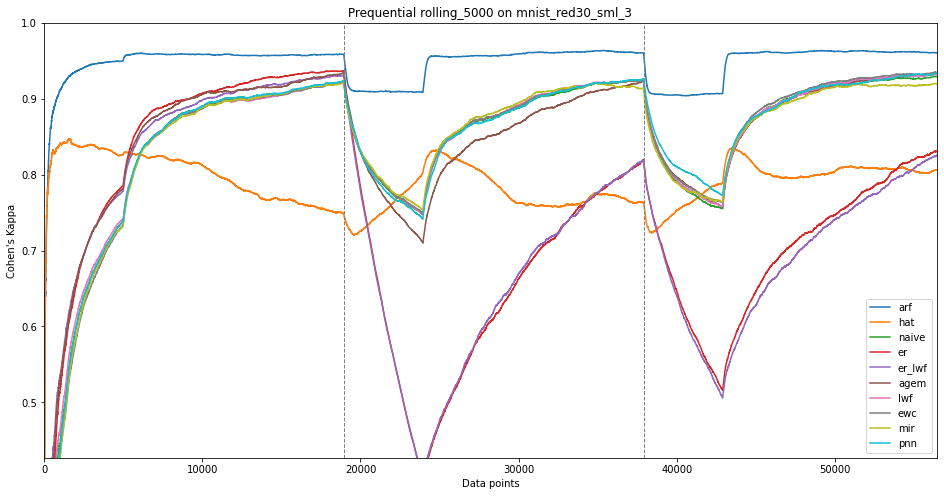

In [4]:
if type(nconfs)==int:
    nconfs = [nconfs] * len(datasets)

for dataset, nconf in zip(datasets, nconfs):
    perf_values = []
    lens = []
    for conf in range(1, nconf+1):
        lens.append(len(pd.read_csv(os.path.join(root, "datasets", f"{dataset}_{conf}conf_train.csv"))))
        with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", f"performance_sml.pkl"), "rb") as f:
            perf_values_ = pickle.load(f)    
    
        with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", "performance_cl.pkl"), "rb") as f:
            p = pickle.load(f)
            del p["drifts"]
            perf_values_.update(p)
    
        for s in suffixes:
            with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", f"performance_cl_{s}.pkl"), "rb") as f:
                p = pickle.load(f)
                del p["drifts"]
                perf_values_.update(p)
            
        perf_values.append(perf_values_)
    
    drifts = [p["drifts"] for p in perf_values]
    for i in range(len(drifts)):
        drifts[i] = [0] + drifts[i] + [lens[i]]
    
    concepts_len = [[d[i+1]-d[i] for i in range(len(d)-1)] for d in drifts]
    concepts_len = np.min(concepts_len, axis=0)
    concepts_len
    
    perf_values_cleaned = pickle.loads(pickle.dumps(perf_values))
    for i in range(len(perf_values)):
        for model in perf_values[i]:
            if model=="drifts":
                continue
            for m in perf_values[i][model]:
                if m=="drifts":
                    continue
                for metric in ['accuracy', 'kappa']:
                    p = perf_values[i][model][m][metric]
                    perf_values_cleaned[i][model][m][metric] = np.concatenate(
                        [
                            p[drifts[i][j]:drifts[i][j]+concepts_len[j]]
                            for j in range(len(concepts_len))
                        ]
                    )
    
    for i in range(len(perf_values_cleaned)):
        perf_values_cleaned[i]["drifts"] = [concepts_len[0]]
        for j in range(1, len(concepts_len)):
            perf_values_cleaned[i]["drifts"].append(perf_values_cleaned[i]["drifts"][-1] + concepts_len[j])
    
    perf_values_final = {}
    for model in perf_values_cleaned[0]:
        if model=="drifts":
            continue
        perf_values_final[model] = {}
        for m in perf_values_cleaned[0][model]:
            if m == "drifts":
                continue
            perf_values_final[model][m] = {}
            for metric in ['accuracy', 'kappa']:
                perf_values_final[model][m][metric] = np.mean([p[model][m][metric] for p in perf_values_cleaned], axis=0)
    
    perf_values_final["drifts"] = perf_values_cleaned[0]["drifts"]

    for perf_type in ["concept"] + [f"rolling_{w}" for w in [500, 1000, 5000]]:
        print(dataset, perf_type)
        plot_kappa(perf_values_final, root=os.path.join(root, "performance"), dataset=dataset, perf=perf_type)
    print()